# Project 1:
# Simulation and estimation in a Markov model of breast cancer

## Part 1

States (columns in P matrix):   
1: Undergone surgery (healthy)   
2: Local reoccurence (cancer)   
3: Distant metastatis (cancer)   
4: Both cancers (cancer)   
5: Death (death)

In [20]:
import math
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

### Task 1

Assume that one time step equals one month. Simulate 1000 women, all starting in state 1, until death.   
Summarize the lifetime distribution of the women, after surgery, for example using a histogram.   
In what proportion of women does the cancer eventually reappear, locally?

In [17]:
### Probability matrix
P = np.array([
    [0.9915, 0.005, 0.0025, 0,     0.001],
    [0,      0.986, 0.005,  0.004, 0.005],
    [0,      0,     0.992,  0.003, 0.005],
    [0,      0,     0,      0.991, 0.009],
    [0,      0,     0,      0,     1    ]
])
print(P[0,:])

### Possible states (0-indexed)
S = np.array([0,1,2,3,4])
print(S)

[0.9915 0.005  0.0025 0.     0.001 ]
[0 1 2 3 4]


In [18]:
#Random seed
np.random.seed(43)
#Number of observations wanted (per sample)
N_obs = 1000
#Initialise states as 0 (healthy)
states = np.zeros(N_obs, dtype=int)

#Initialise lifetimes
lifetimes = np.zeros(N_obs, dtype=int)

#Initialise list for logging states history (to be converted into a matrix)
hist = [states.copy()]

### Time loop
#While there are still women alive
while not np.all(states == 4):

    ### Loop for each woman
    for i in range(N_obs):
        #Extract state
        state = states[i] 

        #Only proceed if not dead
        if state != 4:
            #Extract transistion probability
            prob_trans = P[state,:]

            #Determine transition stochastically
            new_state = np.random.choice(a=S, p=prob_trans)

            #Update state and lifetime
            states[i] = new_state
            lifetimes[i] += 1

    #Log state in history list
    hist.append(states.copy())  

#Convert history into matrix with rows denoting time step, and cols denoting each woman
hist = np.array(hist)

KeyboardInterrupt: 

In [ ]:
### Post-processing
#Compute proportion of women for whom the cancer eventually reappear, locally
#(who has been in state 2)
loc_reocc = 0
for i in range(N_obs):
    woman_i = hist[:,i]
    if np.any(woman_i == 1):
        loc_reocc += 1
loc_reocc /= N_obs

mean_sample = np.mean(lifetimes)
var_sample = np.var(lifetimes, ddof=1)

In [ ]:
###Check results
print("Shape of hist: ", np.shape(hist))
print("Shape of lifetimes: ", np.shape(lifetimes))
print(f"Proportion of local reoccurence:\n{loc_reocc:.4f}")

print("lifetimes of first 10 women:")
print(lifetimes[:10])
print(f"max: {np.max(lifetimes)},  min: {np.min(lifetimes)}")
print(f"mean: {mean_sample:.2f},  stddev: {math.sqrt(var_sample):.2f}")

Shape of hist:  (1358, 1000)
Shape of lifetimes:  (1000,)
Proportion of local reoccurence:
0.5870
lifetimes of first 10 women:
[256 446 388  83 480 249 219 190 382 141]
max: 1357,  min: 1
mean: 258.32,  stddev: 181.88


[-0.5  0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5]


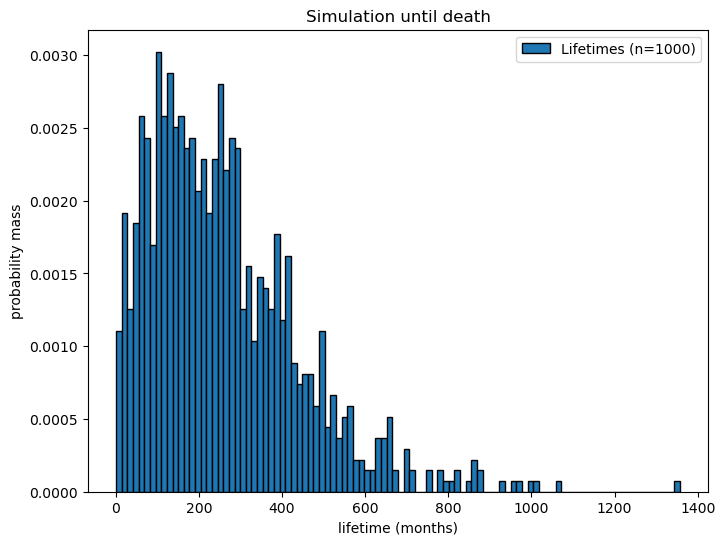

In [ ]:
### Visualising
fig, ax = plt.subplots(figsize=(8,6))

#Edges for histogram with spacing 1
bin_max_val = 10 #last value for centred bin
n_bins = bin_max_val+1
edges = np.linspace(-0.5, bin_max_val+0.5, num=n_bins+1)
print(edges)

ax.hist(
    lifetimes, 
    bins=100,
    density=True,
    edgecolor='black',
    #alpha=0.9,
    label= f"Lifetimes (n={N_obs:.0f})"
)

ax.set_xlabel('lifetime (months)')
ax.set_ylabel('probability mass')
ax.set_title('Simulation until death')
ax.legend()

plt.show()

### Part 2

In your simulations, what is the distribution over the states at t = 120?   
Does this correspond to what we expect? Answer the question using an
appropriate statistical test.

In [ ]:
### Compute expected state for t=120
t=120
#Initialise p_0:
# all women healthy -> all in state 0 -> state 0 has prob 1
p_0 = np.array([1, 0, 0, 0, 0])
#Compute P^t
P_exp_120 = np.linalg.matrix_power(P, t)
#Compute p_t
p_exp_120 = p_0 @ P_exp_120
print("Expected prob. at t=120 (p_120):\n", p_exp_120)
print("checking if sum is 1")
print(np.sum(p_exp_120))

Expected prob. at t=120 (p_120):
 [0.35902627 0.15895604 0.1660869  0.06774149 0.2481893 ]
checking if sum is 1
1.0000000000000027


In [ ]:
### Compute observed  state distribution at t=120

#Extract state at t=120
states_120 = hist[t,:]

#Initialise observed probability
obs_120 = np.zeros(5)

#Count occurences of possible states (0-4)
for i in range(5):
    obs_120[i] = np.sum(states_120==i)


print("Observed frequencies (obs_120):")
print(obs_120)
print("checking if sum is N_samples")
print(np.sum(obs_120))

Observed frequencies (obs_120):
[339. 172. 184.  65. 240.]
checking if sum is N_samples
1000.0


In [ ]:
### Performing chi-squared test as GOF-test, to check how well distribution matches expected
#Compute expected counts
exp_120 = N_obs*p_exp_120
#Checking whether all exp values are above 5:
print("Expected values (ensure that all >5):")
print(exp_120) 
print("Observed values:")
print(obs_120)
### Computing test statistc 
#Number of bins (number of states)
n_bins_chi2 = 5

#Computing test statistic
chi2_test = 0
for i in range(n_bins_chi2):
    chi2_test += (obs_120[i]-exp_120[i])**2 / exp_120[i]

#Computing p_val
p_val = 1-sp.stats.chi2.cdf(x=chi2_test, df=n_bins_chi2-1)

print("Chi2 GOF-results:")
print(f"df: {n_bins_chi2-1}")
print(f"test statistic: {chi2_test:.4f}")
print(f"p-value: {p_val:.4f}")

Expected values (ensure that all >5):
[359.02626821 158.95603979 166.08689731  67.74149395 248.18930075]
Observed values:
[339. 172. 184.  65. 240.]
Chi2 GOF-results:
df: 4
test statistic: 4.5006
p-value: 0.3425


### Task 3

Does your simulated lifetimes follow a discrete phase-type distribution?

It has pmf

$$ P(T=t) = \boldsymbol{\pi(P_s)^t p_s} $$

and mean   

$$E(T) = \boldsymbol{\pi(I - P_s)^{-1}1}$$

In [ ]:
### Computing expected discrete phase-type distribution
#pi: Dist. over states (0-3) at t=0
pi = np.array([1,0,0,0]) 

#P_s: Sub-matrix of P, removing last row and col
P_s = P[:-1,:-1]

#p_s: prob of dying from states (0-3)
# (the last column of P, minus its last row)
p_s = P[:-1, -1]

In [ ]:
#Defining function for pmf and mean
def pmf_phase_type(t, pi=pi, P_s=P_s, p_s=p_s):
    return pi @ np.linalg.matrix_power(P_s,t) @ p_s

def mean_phase_type(pi=pi, P_s=P_s):
    d = np.shape(P_s)[0]
    mat_inv = np.linalg.inv(np.identity(d) - P_s)
    return pi @ mat_inv @ np.ones(d).T 

tgrid = np.arange(1400)
pmf_pt_vals = np.array([pmf_phase_type(t, pi=pi, P_s=P_s, p_s=p_s) for t in tgrid])

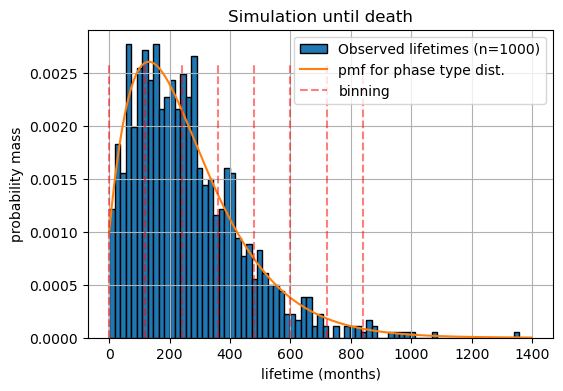

In [ ]:
### Visualising with theoretical pmf

### Visualising
fig, ax = plt.subplots(figsize=(6,4))

#Edges to be used in second chi2 test
#Bin width of ten years
bin_width = 120
#8 ordinary bins
n_ord_bins = 7
edges2 = np.linspace(0, bin_width*n_ord_bins, n_ord_bins+1)

#Edges for histogram with spacing 1
#bin_max_val = 10 #last value for centred bin
##n_bins = bin_max_val+1
#edges = np.linspace(-0.5, bin_max_val+0.5, num=n_bins+1)
#print(edges)

ax.hist(
    lifetimes, 
    bins=75,
    density=True,
    edgecolor='black',
    #alpha=0.9,
    label= f"Observed lifetimes (n={N_obs:.0f})"
)

ax.plot(
    tgrid,
    pmf_pt_vals,
    label="pmf for phase type dist."
)

ax.vlines(edges2, 
          0, 
          max(pmf_pt_vals),
          label='binning',
          color='red',
          linestyles='--',
          alpha=0.5)

ax.set_xlabel('lifetime (months)')
ax.set_ylabel('probability mass')
ax.set_title('Simulation until death')
ax.legend()
ax.grid()

plt.show()

In [ ]:
### Checking sample mean and theoretical mean:
mean_ana = mean_phase_type()

print(f"Sample mean: {mean_sample:.3f}")
print(f"Mean of phase type dist (true mean).: {mean_ana:.3f}")

Sample mean: 258.316
Mean of phase type dist.: 262.372


In [ ]:
### Creating binning for chi2 test
print("bin edges (excl. infinity):")
print(edges2)

# Counting observations in 8 bins + 1 tail bin

def observed_counts(x, edges):
    # Extend last bin to infinity
    extended_edges = np.append(edges, np.inf)
    counts, _ = np.histogram(x, bins=extended_edges)
    return counts

obs2 = observed_counts(lifetimes, edges2)
print("Observed2:")
print(obs2)

def expected_counts(pmf, edges, n):
    expected = []
    
    # Regular bins
    for i in range(len(edges) - 1):
        
        a, b = edges[i], edges[i+1]
        prob = sum(pmf(k) for k in range(int(a), int(b)))
        expected.append(n * prob)
    
    # Last bin: from last edge to infinity
    a = edges[-1]
    prob_tail = 0
    k = int(a)
    
    # sum until probability is negligible
    while True:
        p = pmf(k)
        if p < 1e-12:   # stopping condition
            break
        prob_tail += p
        k += 1
    
    expected.append(n * prob_tail)
    
    return np.array(expected)

exp2 = expected_counts(pmf=pmf_phase_type, edges=edges2, n=N_obs)

print("Expected2:")
print(exp2)

print("checking whether both lists sum to N_samples")
print(np.sum(obs2))
print(np.sum(exp2))


bin edges (excl. infinity):
[  0. 120. 240. 360. 480. 600. 720. 840.]
Observed2:
[235 295 221 138  61  29   8  13]
Expected2:
[248.18930075 293.97284798 209.55302721 123.12380115  65.15085337
  32.26818474  15.26793079  12.47405388]
checking whether both lists sum to N_samples
1000
999.9999998723913


In [ ]:
### Performing chi-squared test as GOF-test, to check how well distribution matches expected
#Compute expected counts
#Checking whether all exp values are above 5:
print("Expected values (ensure that all >5):")
print(exp2) 
print("Observed values:")
print(obs2)
### Computing test statistc 
#Number of bins (number of states)
n_bins_chi2 = len(exp2)
print("number of bins")
print(n_bins_chi2)

#Computing test statistic
chi2_test = 0
for i in range(n_bins_chi2):
    chi2_test += (obs2[i]-exp2[i])**2 / exp2[i]

#Computing p_val
p_val = 1-sp.stats.chi2.cdf(x=chi2_test, df=n_bins_chi2-1)

print("----Chi2 GOF-results:----")
print(f"df: {n_bins_chi2-1}")
print(f"test statistic: {chi2_test:.4f}")
print(f"p-value: {p_val:.4f}")

Expected values (ensure that all >5):
[248.18930075 293.97284798 209.55302721 123.12380115  65.15085337
  32.26818474  15.26793079  12.47405388]
Observed values:
[235 295 221 138  61  29   8  13]
number of bins
8
----Chi2 GOF-results:----
df: 7
test statistic: 7.2045
p-value: 0.4079


### Part 4

Estimate the expected lifetime, after surgery, of a woman who survives the
first 12 months following surgery, but whose breast cancer has also reappeared within the first 12 months, either locally or distant.

Hint: Use rejection sampling. Simulate a number of women, and discard
all simulations that do not meet the requirements. Do this until you have
reached 1000 acceptable simulations.

In [ ]:
#Random seed
np.random.seed(43)
#Number of observations wanted
N_obs = 1000
#Initialise lifetimes
lifetimes = []
#Initialise variables tracking number of simulated women
women_all_count = 0
#Initialise state variable tracking how many women satisfies having reoccuring canser (state 1,2 or 3) 
#and being alive after first 12 months
survive_reocc_count = 0
#Initialise list for logging states history for women passing crit (for verifying simulation)
hist_pass = []
#Initialise list for logging states history for women failing crit (for verifying simulation)
hist_fail = []

print("Beginning simulation...")

### Loop for each woman - until lifetimes for women meeting criteria have been simulated
#while there are still women alive
while survive_reocc_count < N_obs:
    #Initialise state history for woman
    state = 0
    state_hist_i = [state]

    #Initialise lifetime = 0
    lifetime_i = 0

    #Initialise pass-criterium state (not passed by default)
    survive_reocc_i = False

    ### Time loop 
    #While women is not dead
    while state != 4:
        #Extract transistion probability
        prob_trans = P[state,:]

        #Determine transition stochastically
        new_state = np.random.choice(a=S, p=prob_trans)

        #Update lifetime and log new state in history
        lifetime_i += 1
        state_hist_i.append(new_state)

        #Update state
        state = state_hist_i[-1]

        #check if criterium is met at t=13: break if not
        if lifetime_i == 12:
            #Check whether women has had no state in [1,2,3]
            if any(x in [1,2,3] for x in state_hist_i):
                survive_reocc_i = True
            else:
                break

    #if criterium is met: increse counter, log the lifetime, and log the state history for woman in history list 
    if survive_reocc_i == True:
        survive_reocc_count += 1
        lifetimes.append(lifetime_i)
        hist_pass.append(state_hist_i) 
    else:
        hist_fail.append(state_hist_i)

    #Increase woman counter
    women_all_count += 1 

print("Simulation done!")

Beginning simulation...
Simulation done!


In [ ]:
### Check results
mean_sample_t4 = np.mean(lifetimes)
print(f"Expected lifetime of women passing criterium:\n{mean_sample_t4:.2f} months\n {mean_sample_t4/12:.2f} years")

print("Length of lifetimes:", len(lifetimes))
print("Number of women failing criterium: ", len(hist_fail))
print(f"Number of women simulated: {women_all_count}")
print(f"Fraction of simulated women meeting criterium: {survive_reocc_count/women_all_count:.3f}")

print("Example of history of women passing crit")
print(hist_pass[0])
print("Example of history of women failing crit")
print(hist_fail[0])

Expected lifetime of women passing criterium:
174.16 months
 14.51 years
Length of lifetimes: 1000
Number of women failing criterium:  10684
Number of women simulated: 11684
Fraction of simulated women meeting criterium: 0.086
Example of history of women passing crit
[0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4]
Example of history of women failing crit
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


[-0.5  0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5]


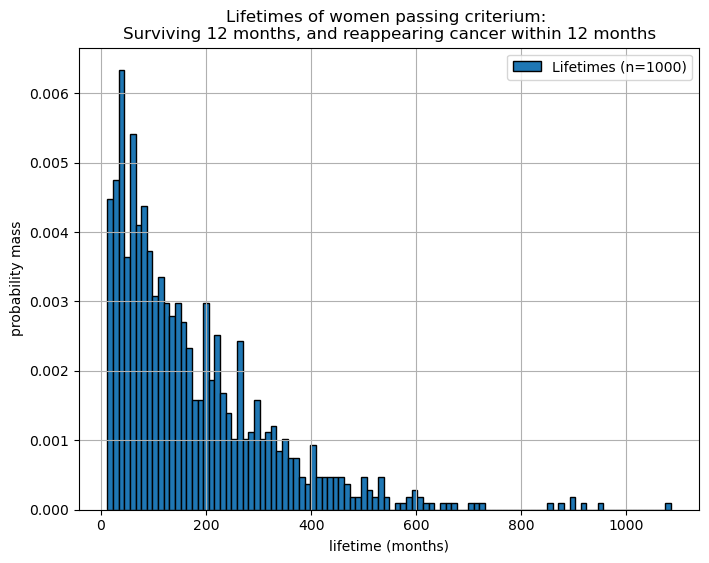

In [ ]:
### Visualising
fig, ax = plt.subplots(figsize=(8,6))

#Edges for histogram with spacing 1
bin_max_val = 10 #last value for centred bin
n_bins = bin_max_val+1
edges = np.linspace(-0.5, bin_max_val+0.5, num=n_bins+1)
print(edges)

ax.hist(
    lifetimes, 
    bins=100,
    density=True,
    edgecolor='black',
    #alpha=0.9,
    label= f"Lifetimes (n={N_obs:.0f})"
)

ax.set_xlabel('lifetime (months)')
ax.set_ylabel('probability mass')
ax.set_title('Lifetimes of women passing criterium: \nSurviving 12 months, and reappearing cancer within 12 months')
ax.legend()
ax.grid()

plt.show()

### Task 5

What fraction of women die within the first 350 months? Answer this by
simulating 200 women, and record the fraction. Do this 100 times. Use con-
trol variates to reduce the variance.

How large a reduction in variance do you see, using control variates, as op-
posed to the crude Monte Carlo estimator?

Hint: Use the mean lifetime after surgery of the 200 simulations as the
control variate.

In [ ]:
### Same simulation, but with using control variates (now women living longer than 350 months have to be simulated as well)
#Random seed
np.random.seed(43)
#Number of observations wanted (per sample)
N_obs = 200
#Number of samples wanted
N_samples = 100

#Initialise history of results
list_main_variable = []
#Initialise history for control varites
list_control_variates = []
#Initialise list for logging states history for women passing crit (for verifying simulation)
hist_pass = []
#Initialise list for logging states history for women failing crit (for verifying simulation)
hist_fail = []

print("Beginning simulation...")

### Loop for each woman - until lifetimes for women meeting criteria have been simulated
#while there are still women alive

for i in range(N_samples):

    #Initialise state variable tracking how many women satisfies criterium: 
    # dying within first 350 months
    crit_pass_count = 0

    #Initialise variables tracking number of simulated women
    women_all_count = 0

    #Initialise lifetimes 
    lifetimes = []
    
    #Create 1 sample of N_obs women
    while women_all_count < N_obs:
        #Initialise state history for woman
        state = 0
        state_hist_i = [state]

        #Initialise lifetime = 0
        lifetime_i = 0

        #Initialise pass-criterium state (not passed by default)
        crit_pass_i = True

        ### Time loop 
        #While women is not dead
        while state != 4:
            #Extract transistion probability
            prob_trans = P[state,:]

            #Determine transition stochastically
            new_state = np.random.choice(a=S, p=prob_trans)

            #Update lifetime and log new state in history
            lifetime_i += 1
            state_hist_i.append(new_state)

            #Update state
            state = state_hist_i[-1]

            #If women is not dead before t=350 and  crit is not (yet) failed: fail criterium
            if lifetime_i == 350 and crit_pass_i==True:
                crit_pass_i = False

        #Log lifetime 
        lifetimes.append(lifetime_i)
        
        #if criterium is met: increse counter, and log the state history for woman in history list 
        if crit_pass_i == True:
            crit_pass_count += 1
            hist_pass.append(state_hist_i) 
        else:
            hist_fail.append(state_hist_i)

        #Increase simulated woman counter
        women_all_count += 1 
    
    #Compute result
    frac_pass_t5 = crit_pass_count/women_all_count
    #Append result
    list_main_variable.append(frac_pass_t5)

    #Compute and append control variate (mean of lifetime)
    control_variate = np.mean(lifetimes)
    list_control_variates.append(control_variate)

    #Simulation Status
    if (i+1)%20 == 0:
        print(f"simulation {i+1} done")

#Convert to np.array
list_main_variable = np.array(list_main_variable)
list_control_variates = np.array(list_control_variates)

print("Simulation done!")

Beginning simulation...
simulation 20 done
simulation 40 done
simulation 60 done
simulation 80 done
simulation 100 done
Simulation done!


In [ ]:
### Save/load resutls as/from npy file
np.save("Results_varred_mainvar_task5.npy",list_main_variable)
np.save("Results_varred_contrvar_task5.npy",list_control_variates)
#list_main_variable = np.load("Results_varred_mainvar_task5.npy", allow_pickle=True)
#list_control_variable = np.load("Results_varred_contrvar_task5.npy", allow_pickle=True)

In [ ]:
#Check results
print("Crude MC: First 10 results:\n",list_main_variable[:10])
print("CV: First 10 results:\n",list_control_variates[:10])

print("\nSanity checks:")
print("Number of women failing criterium: ", len(hist_pass))
print("Number of women failing criterium: ", len(hist_fail))
print(f"Number of women simulated: {N_obs*N_samples}")

print("Example of history of women passing crit")
print(hist_pass[0])
print("Example of history of women failing crit")
print(hist_fail[0])

Crude MC: First 10 results:
 [0.725 0.7   0.74  0.75  0.75  0.68  0.76  0.76  0.755 0.735]
CV: First 10 results:
 [262.745 273.905 259.14  247.235 256.385 275.885 254.9   259.625 270.875
 260.445]

Sanity checks:
Number of women failing criterium:  14789
Number of women failing criterium:  5211
Number of women simulated: 20000
Example of history of women passing crit
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4]
Example of history of women failing crit
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [ ]:
### Compute new variable with reduced variance

## Computing c
#Covariance of main and control raiable
cov_xz_mat = np.cov(list_main_variable, list_control_variates)
cov_xz = cov_xz_mat[0,1]
var_z = cov_xz_mat[1,1]
c = - cov_xz / var_z
print(f"cov_xz: {cov_xz:.2g}")
print(f"var_z: {var_z:.2g}")
print(f"c: {c:.2g}")

## Construct new variable, Y
#mean of lifetime (true mean)
mu_z = mean_phase_type()
print(f"mu_z (true): {mu_z:.2f}")
#New variable
Y = list_main_variable + c*(list_control_variates-mu_z)

cov_xz: -0.37
var_z: 1.9e+02
c: 0.0019
mu_z (true): 262.37


In [ ]:
### Compare crude MC with Control Variate estmator

#Crude MC estimator
frac_MC_est = np.mean(list_main_variable)
frac_MC_var = np.var(list_main_variable, ddof=1)

#Control Variate estimator
frac_CV_est = np.mean(Y)
frac_CV_var = np.var(Y, ddof=1)

#Relative reduction in variance
var_rel_reduc = (frac_CV_var-frac_MC_var)/frac_MC_var

print(f"Crude MC estimator: {frac_MC_est:.3g}")
print(f"Crude MC variance: {frac_MC_var:.3g}")
print(f"Crude CV estimator: {frac_CV_est:.3g}")
print(f"Crude CV variance: {frac_CV_var:.3g}")
print(f"Relative reduction in variance: {var_rel_reduc*100:.2f} %")

Crude MC estimator: 0.739
Crude MC variance: 0.00113
Crude CV estimator: 0.738
Crude CV variance: 0.000426
Relative reduction in variance: -62.27 %


### Task 6

For the report, consider the following questions: What assumptions underlie
the discrete time Markov chain model? Are those assumptions realistic? How
may we relax some of these assumptions, possibly at the cost of increased
model complexity?

Assumptions:
1) Women can go from only having local cancer to only having distant metastatis (unrealistic)
2) The probabilities are time-stationary: having had cancer for a long time, doesn't change the prob of transitioning into death (any state only rely on previous state - common property of any Markov Chain)
3) Women cant go from any cancer state to a non-cancer state (cannot jump to state 1 from other states), as seen from 0-vals in first cols


## Part 2

In [21]:
import math
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [22]:
### Given transition rate matrix
Q = np.array([
    [-0.0085,  0.0050,  0.0025,  0.0000,  0.0010],
    [ 0.0000, -0.01400, 0.0050,  0.0040,  0.0050],
    [ 0.0000,  0.0000, -0.0080,  0.0030,  0.0050],
    [ 0.0000,  0.0000,  0.0000,  -0.009,  0.0090],
    [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000]
])
print(Q)

### Possible states (0-indexed)
S = np.array([0,1,2,3,4])
print(S)

[[-0.0085  0.005   0.0025  0.      0.001 ]
 [ 0.     -0.014   0.005   0.004   0.005 ]
 [ 0.      0.     -0.008   0.003   0.005 ]
 [ 0.      0.      0.     -0.009   0.009 ]
 [ 0.      0.      0.      0.      0.    ]]
[0 1 2 3 4]


### Task 7

In [105]:
#Random seed
np.random.seed(43)
#Number of observations wanted
N_obs = 1000
#Initialise lifetimes
lifetime_list_t7 = []
#Initialise variables tracking number of simulated women
women_all_count = 0
#Initialise list for logging states history for women
state_hist_list = []
#Initialise list for logging times at which transitions happens
time_hist_list = []
#Initialise passed criterium counter
crit_pass_count = 0

print("Beginning simulation...")

### Loop for each woman - until lifetimes for women meeting criteria have been simulated
while women_all_count < N_obs:
    #Initialise state history for woman
    state = 0
    state_hist = [state]

    #Initialise time history for women
    lifetime = 0
    time_hist = [lifetime]

    #Pass crit variable (to not double count)
    crit_pass = False

    ### Time loop 
    #While women is not dead
    while state != 4:
        #Determine sojurn time rate from current state
        rate_soj = -Q[state, state]

        #Determine sojurn time stochastically (how long time women remains in state)
        t_soj = sp.stats.expon.rvs(scale = 1/rate_soj)
 
        #Update lifetime 
        lifetime += t_soj

        #Extract transition probability (use copy due to how python lists work)
        prob_trans = Q[state,:].copy() / rate_soj
        prob_trans[state] = 0

        #Determine transition stochastically
        new_state = np.random.choice(a=S, p=prob_trans)

        #log new state and time in history
        state_hist.append(new_state)
        time_hist.append(lifetime)

        #Update state
        state = state_hist[-1]

        #Check criterium (women in state 2 or 3 after 30.5 months)
        if state in [2,3]:
            if lifetime > 30.5:
                if crit_pass == False:
                    crit_pass_count += 1
                    crit_pass == True

    #log the lifetime, and log the state history for woman in history list 
    lifetime_list_t7.append(lifetime)
    state_hist_list.append(state_hist)
    time_hist_list.append(time_hist)

    #Increase woman counter
    women_all_count += 1 

print("Simulation done!")

Beginning simulation...
Simulation done!


In [106]:
### Check results
mean_sample_t7 = np.mean(lifetime_list_t7)
frac_t7 = crit_pass_count/women_all_count
print(f"Expected lifetime of women:\n{mean_sample_t7:.2f} months\n {mean_sample_t7/12:.2f} years")
print(f"Proportion of women where cancer reappears distantly after 30.5 months:\n{frac_t7:.3g}")


print("Length of lifetimes:", len(lifetime_list_t7))
print(f"Number of women simulated: {women_all_count}")

print("first vals of lifetimes:")
print(lifetime_list_t7[:10])
print("Example of state_hist:")
print(state_hist_list[1])
print("Example of time_hist:")
print(time_hist_list[1])

Expected lifetime of women:
273.00 months
 22.75 years
Proportion of women where cancer reappears distantly after 30.5 months:
0.793
Length of lifetimes: 1000
Number of women simulated: 1000
first vals of lifetimes:
[76.29990039798255, 131.14830093295444, 319.67347024541425, 66.77673667947276, 222.361473915385, 57.26424329314554, 80.19278715954133, 113.71553994777656, 450.1217604658465, 673.6413939383947]
Example of state_hist:
[0, 1, 4]
Example of time_hist:
[0, 129.04522606878265, 131.14830093295444]


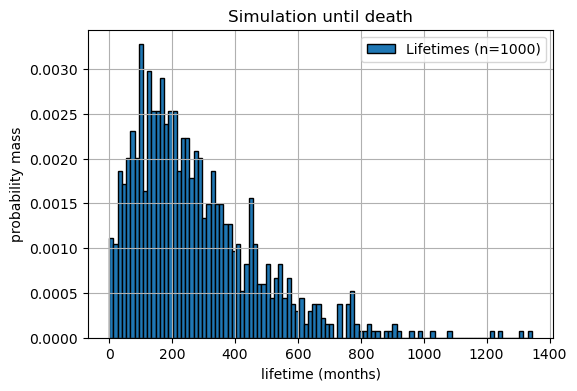

In [121]:
### Visualising
fig, ax = plt.subplots(figsize=(6,4))

ax.hist(
    lifetime_list_t7, 
    bins=100,
    density=True,
    edgecolor='black',
    #alpha=0.9,
    label= f"Lifetimes (n={N_obs:.0f})"
)

ax.set_xlabel('lifetime (months)')
ax.set_ylabel('probability mass')
ax.set_title('Simulation until death')
ax.legend()
ax.grid()

plt.show()

### Task 8

Compare the emperical lifetime distribution function, from your simulations,
to the theoretical, using an appropriate statistical test.

In [108]:
#Emperical distribution function
def F_n(x, obs):
    # number of observations
    n = np.size(obs)
    #Computing F_n by number of observations smaller that x for each x
    vals = np.zeros(np.size(x)) 
    for i in range(len(x)):
        vals[i] = (1/n) * np.sum(obs <= x[i])
    return vals

In [109]:
### Construct parameters for Continuous time phase-type distribution
#Submatrix of Q, minus last row and col
Q_s = Q[:-1,:-1].copy()
#Initial state, minus last element
p_0 = np.array([1,0,0,0])

def cdf_CTPT(t, p_0=p_0, Q_s=Q_s):
    d = np.shape(Q_s)[0]
    n = np.size(t)
    vals = np.zeros(n)
    for i in range(n):
        mat_exp = sp.linalg.expm(Q_s*t[i])
        mat_prod = p_0 @ mat_exp @ np.ones(d)
        vals[i] = 1 - mat_prod
    return vals

### Compute cdf vals
tgrid = np.linspace(0, 1200, num=1000)
#cdf_ctpt_vals = np.array([ cdf_CTPT(t) for t in tgrid])
cdf_ctpt_vals = cdf_CTPT(tgrid)
cdf_emp_vals = F_n(x=tgrid, obs=lifetime_list_t7)

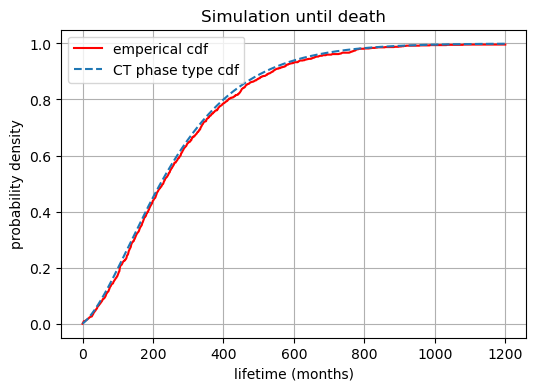

In [ ]:
### Visualising with theoretical cdf
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(
    tgrid,
    cdf_emp_vals,
    label="emperical cdf",
    color='red'
)

ax.plot(
    tgrid,
    cdf_ctpt_vals,
    label="CT phase type cdf",
    linestyle='--'
)

ax.set_xlabel('lifetime (months)')
ax.set_ylabel('probability density')
ax.set_title('Simulation until death')
ax.legend()
ax.grid()

plt.show()

In [111]:
### KS test af GOF test

print("Own computation")
# Computing KS test statistics (non-adjusted)
D_n = np.max(np.abs(cdf_emp_vals-cdf_ctpt_vals))
print(f"D_n: {D_n:.4g}")

# Computing adjusted test statistic
D_n_adj = (np.sqrt(N_obs) + 0.12 +  0.11/np.sqrt(N_obs))*D_n
print(f"adjusted D_n: {D_n_adj:.4g}")

# Computing the p-value form the cdf
cdf_val = sp.stats.kstwo.cdf(D_n, n=N_obs)
p_val = 1-cdf_val
print(f"p_val: {p_val:.4g}")

D_n_kstest, p_val_kstest = sp.stats.kstest(rvs=lifetime_list_t7, cdf=cdf_CTPT)
print("Using kstest from scipy.stats")
print(f"D_n_kstest: {D_n_kstest:.4g}")
print(f"p_val_kstest: {p_val_kstest:.4g}")


Own computation
D_n: 0.02592
adjusted D_n: 0.8227
p_val: 0.5045
Using kstest from scipy.stats
D_n_kstest: 0.02657
p_val_kstest: 0.4723


med n=1000 gridpunkter   
D_n: 0.025915338111439618   
cdf_val: 0.496   
p_val: 0.504   

med n=2000 gridpunkter   
D_n: 0.025755017756458137   
cdf_val: 0.487   
p_val: 0.513   

med n=4000 gridpunkter   
D_n: 0.02600708041833885   
cdf_val: 0.5001   
p_val: 0.4999   

### Part 9

A certain preventitive treatment results in the following transition-rate matrix instead:   
...   
Simulate 1000 women who have received this treatment. Plot the Kaplan-
Meier estimate of the survival function. In the same figure, plot the Kaplan-
Meier estimate of the survival function for women, who have not received
this treatment. Does the treatment appear to have an effect

In [112]:
### Compute missing diagonal values of new Q
row0 = np.array([0.0025, 0.00125, 0,     0.001]) 
row1 = np.array([0, 0, 0.002, 0.005])
row2 = np.array([0, 0, 0.003, 0.005])
row3 = np.array([0, 0, 0, 0.009])
row4 = np.array([0, 0, 0, 0])
rows = [row0, row1, row2, row3, row4]

for i in range(len(diagonals)):
    diagonal = -np.sum(rows[i])
    rows[i] = np.insert(rows[i], i, diagonal)

Qtreat = np.array(rows)
print("Q treatment:")
print(Qtreat)

Q treatment:
[[-0.00475  0.0025   0.00125  0.       0.001  ]
 [ 0.      -0.007    0.       0.002    0.005  ]
 [ 0.       0.      -0.008    0.003    0.005  ]
 [ 0.       0.       0.      -0.009    0.009  ]
 [ 0.       0.       0.       0.       0.     ]]


In [113]:
#Random seed
np.random.seed(43)
#Number of observations wanted
N_obs = 1000
#Initialise list for logging lifetimes
lifetime_list_t9 = []
#Initialise variables tracking number of simulated women
women_all_count = 0
#Initialise list for logging state histories for women
state_hist_list = []
#Initialise list for logging times at which transitions happens
time_hist_list = []
#Initialise passed criterium counter
crit_pass_count = 0

print("Beginning simulation...")

### Loop for each woman - until lifetimes for women meeting criteria have been simulated
while women_all_count < N_obs:
    #Initialise state history for woman
    state = 0
    state_hist = [state]

    #Initialise time history for women
    lifetime = 0
    time_hist = [lifetime]

    ### Time loop 
    #While women is not dead
    while state != 4:
        #Determine sojurn time rate from current state
        rate_soj = -Qtreat[state, state]

        #Determine sojurn time stochastically (how long time women remains in state)
        t_soj = sp.stats.expon.rvs(scale = 1/rate_soj)

        #Update lifetime 
        lifetime += t_soj

        #Extract transition probability (use copy due to how python lists work)
        prob_trans = Qtreat[state,:].copy() / rate_soj
        prob_trans[state] = 0

        #Determine transition stochastically
        new_state = np.random.choice(a=S, p=prob_trans)

        #log new state and time in history
        state_hist.append(new_state)
        time_hist.append(lifetime)

        #Update state
        state = state_hist[-1]

    #log the lifetime, and log the state history for woman in history list 
    lifetime_list_t9.append(lifetime)
    state_hist_list.append(state_hist)
    time_hist_list.append(time_hist)

    #Increase woman counter
    women_all_count += 1 

print("Simulation done!")

Beginning simulation...
Simulation done!


In [ ]:
### Check results
mean_sample_t9 = np.mean(lifetime_list_t9)
print(f"Expected lifetime of women:\n{mean_sample_t9:.2f} months\n {mean_sample_t9/12:.2f} years")

print("Length of lifetimes:", len(lifetime_list_t9))
print(f"Number of women simulated: {women_all_count}")

print("first vals of lifetimes:")
print(lifetime_list_t9[:5])
print("Example of state_hist:")
print(state_hist_list[1])
print("Example of time_hist:")
print(time_hist_list[1])

Expected lifetime of women:
365.68 months
 30.47 years
Length of lifetimes: 1000
Number of women simulated: 1000
first vals of lifetimes:
[87.65246629389691, 234.60341713538537, 105.77772846316442, 407.31955117604394, 16.79172051481303]
Example of state_hist:
[0, 2, 4]
Example of time_hist:
[0, 230.92303612308476, 234.60341713538537]


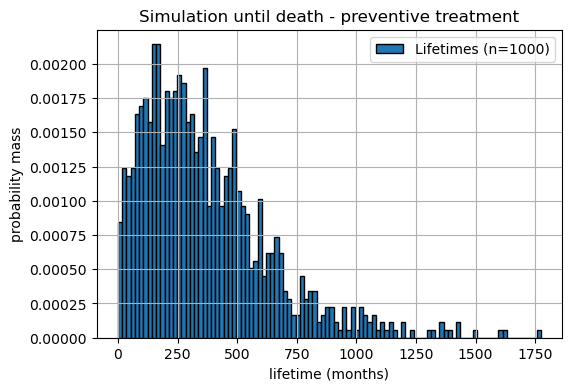

In [120]:
### Visualising
fig, ax = plt.subplots(figsize=(6,4))

ax.hist(
    lifetime_list_t9, 
    bins=100,
    density=True,
    edgecolor='black',
    #alpha=0.9,
    label= f"Lifetimes (n={N_obs:.0f})"
)

ax.set_xlabel('lifetime (months)')
ax.set_ylabel('probability mass')
ax.set_title('Simulation until death - preventive treatment')
ax.legend()
ax.grid()

plt.show()

In [134]:
### Kaplan-Meier estimator
def DiedWomen(t, obs):
    vals = np.zeros(np.size(t)) 
    for i in range(len(t)):
        vals[i] = np.sum(obs <= t[i])
    return vals

def KaplamMeierEstimator(t, obs, d=DiedWomen):
    N = len(obs)
    return (N-d(t=t, obs=obs))/N 

tgrid = np.linspace(0, 2000, num=2001)
KM_vals_t7 = KaplamMeierEstimator(t=tgrid, obs=lifetime_list_t7)
KM_vals_t9 = KaplamMeierEstimator(t=tgrid, obs=lifetime_list_t9)

print(np.shape(KM_vals_t9))


(2001,)


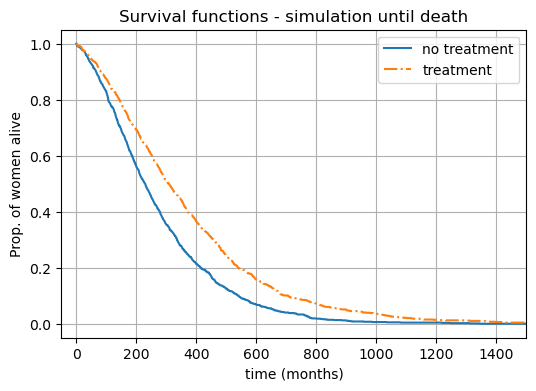

In [143]:
### Visualising the two survival functions
fig, ax = plt.subplots(figsize=(6,4))

ax.plot(
    tgrid,
    KM_vals_t7,
    label="no treatment",
    )

ax.plot(
    tgrid,
    KM_vals_t9,
    label="treatment",
    linestyle='-.'
    )

ax.set_xlabel('time (months)')
ax.set_ylabel('Prop. of women alive')
ax.set_title('Survival functions - simulation until death')
ax.legend()
ax.grid()
ax.set_xlim(-50,1500)

plt.show()

### Task 11

For the report, consider the following questions: What assumptions have
been eliminated, by going from the discrete to the continuous time model?
What have been added? How could the model be extended, such that the
sojourn times are Erlang distributed?

Assumptions removed:
1) discrete -> continuous: Women can not only transition state once per month (they  are 'checked' continiously)

Assumptions added:
1) Transition states are exponentially distributed

Extension/modification, such that sojourn times are Erlang distributed:   
A variable which is Erlang dist. with params $(k,\lambda)$ can be obtained by summing $k$ variables which are exponential distributed with rate paramter $\lambda$.   
So Sojourn times can  be Erlang distributed, if the variable is created by taking sum of previous variables exponential distributed variables. 


## Part 3

### Task 12

Simulate 1000 women, starting in state 1, until death, using the same Q
as in the previous part. For each of the women, create a vector (or time
series) of her observed states Y(i). A time series will consist of the values
Y(i) = (X(0), X(48), X(96), . . . , ). The time series should continue until
death, thus the last value in each of the time series should be 5.

NB: Simulate, and then create time series vectors, which is each woman's state evaluated every 48 months

In [237]:
#Random seed
np.random.seed(43)
#Number of observations wanted
N_obs = 1000
#Initialise list for logging lifetimes
lifetime_list_t12 = []
#Initialise variables tracking number of simulated women
women_all_count = 0
#Initialise list for logging state histories for women
state_hist_list_t12 = []
#Initialise list for logging times at which transitions happens
time_hist_list_t12 = []

print("Beginning simulation...")

### Loop for each woman - until lifetimes for women meeting criteria have been simulated
while women_all_count < N_obs:
    #Initialise state history for woman
    state = 0
    state_hist = [state]

    #Initialise time history for women
    lifetime = 0
    time_hist = [lifetime]

    ### Time loop 
    #While women is not dead
    while state != 4:
        #Determine sojurn time rate from current state
        rate_soj = -Qtreat[state, state]

        #Determine sojurn time stochastically (how long time women remains in state)
        t_soj = sp.stats.expon.rvs(scale = 1/rate_soj)

        #Update lifetime 
        lifetime += t_soj

        #Extract transition probability 
        prob_trans = -Qtreat[state,:].copy() / Qtreat[state,state]
        prob_trans[state] = 0

        #Determine transition stochastically
        new_state = np.random.choice(a=S, p=prob_trans)

        #log new state and time in history
        state_hist.append(new_state)
        time_hist.append(lifetime)

        #Update state
        state = state_hist[-1]

    #log the lifetime, and log the state history for woman in history list 
    lifetime_list_t12.append(lifetime)
    state_hist_list_t12.append(state_hist)
    time_hist_list_t12.append(time_hist)

    #Increase woman counter
    women_all_count += 1 

print("Simulation done!")

Beginning simulation...
Simulation done!


In [238]:
### Check results
mean_sample_t12 = np.mean(lifetime_list_t12)
print(f"Expected lifetime of women:\n{mean_sample_t12:.2f} months\n {mean_sample_t12/12:.2f} years")

print("Length of lifetimes:", len(lifetime_list_t12))
print(f"Number of women simulated: {women_all_count}")

idx=0
print("first vals of lifetimes:")
print(lifetime_list_t12[:5])
print("Example of state_hist:")
print(state_hist_list_t12[idx])
print("Example of time_hist:")
print(time_hist_list_t12[idx])

Expected lifetime of women:
365.68 months
 30.47 years
Length of lifetimes: 1000
Number of women simulated: 1000
first vals of lifetimes:
[87.65246629389691, 234.60341713538537, 105.77772846316442, 407.31955117604394, 16.79172051481303]
Example of state_hist:
[0, 2, 3, 4]
Example of time_hist:
[0, 25.732482697405892, 43.62840057107899, 87.65246629389691]


In [263]:
#Function for creating time series
def coarse_time_series(time_hist, state_hist, step=48):
    time_hist = np.asarray(time_hist)
    state_hist = np.asarray(state_hist)

    # Create coarse grid up to the last time
    t_max = time_hist[-1]
    coarse_times = np.arange(0, t_max + step, step)

    # Find indices of active states
    idx = np.searchsorted(time_hist, coarse_times, side="right") - 1
    idx = np.clip(idx, 0, len(state_hist) - 1)

    ts_state = state_hist[idx]

    # Ensure last value is the final state (e.g., death = 4)
    ts_state[-1] = state_hist[-1]

    return ts_state, coarse_times

### Example
i = 4
lifetime_i = lifetime_list_t12[i]
time_hist_i = time_hist_list_t12[i]
state_hist_i = state_hist_list_t12[i]

print("Example of state_hist:")
print(state_hist_i)
print("Example of time_hist:")
print(time_hist_i)

ts_state, ts_time  = coarse_time_series(time_hist_i, state_hist_i)
print("coarse time grid")
print(ts_time)
print("time series of states")
print(ts_state)


Example of state_hist:
[0, 4]
Example of time_hist:
[0, 16.79172051481303]
coarse time grid
[ 0. 48.]
time series of states
[0 4]


In [266]:
### Apply time_series maker
ts_states_list = []
ts_times_list = []

for i in range(N_obs):
    #Extract time and state history
    time_hist_i = time_hist_list_t12[i]
    state_hist_i = state_hist_list_t12[i]
    #Convert to coarse time series
    ts_state, ts_time  = coarse_time_series(time_hist_i, state_hist_i)
    #Append
    ts_states_list.append(ts_state)
    ts_times_list.append(ts_time)

i = 5
print("time series states:")
print(ts_states_list[i])
print("time series times:")
print(ts_times_list[i])

time series states:
[0 0 0 0 0 0 0 0 0 4]
time series times:
[  0.  48.  96. 144. 192. 240. 288. 336. 384. 432.]


### Task 13

For the remainder of this part, we will assume those 1000 time series is all
we have observed.   
It can be shown that an unbiased estimator of the transition rates, $q_{ij}$ , is

$$ q_{ij} = \frac{N_{ij}}{S_i} \quad \mathrm{for} \quad i \neq j $$

Where $N_{ij}$ is the total number of jumps (for all of the women) from state i
to j, and $S_i$ is the total sojourn time in state i (for all of the women). The
diagonal elements are found from equation (1). The problem is that $N_{ij}$ and
$S_i$ are unknown, all we know are the timeseries of observations every 4’th
year.
One approach to estimation is to recreate $N_{ij}$ and $S_i$ from the partial infor-
mation that we have observed

In [ ]:
### Initialise Q0
# Initialise all upper triangular elements in Q0 (excluding diagonal) with values drawn from standard uniform dist. 
np.random.seed(42)
Q0 = np.random.rand(5,5)
Q0 = np.tril(Q0, k=-1).T

#Compute diagonals
for i in range(5):
    diag_elem = -np.sum(Q0[i,:])
    Q0[i,i] = diag_elem

print("Q0 matrix: ")
print(Q0)
print("Checking that all rows sum to 0:")
print(np.sum(Q0, axis=1))

Q0: 
[[-0.97183642  0.15599452  0.02058449  0.18340451  0.61185289]
 [ 0.         -1.41364596  0.96990985  0.30424224  0.13949386]
 [ 0.          0.         -0.81690108  0.52475643  0.29214465]
 [ 0.          0.          0.         -0.36636184  0.36636184]
 [ 0.          0.          0.          0.         -0.        ]]
Checking that all rows sum to 0:
[0. 0. 0. 0. 0.]


In [ ]:
### Part 1 in algorithm
#Initialise Qk matrix
Qk = Q0.copy()
#Initialise Si, list for sojourn times in each state (for all states except death)
Si = np.zeros(len(states)-1)
#Initialise N_ij matrix, number of jumps from state i tom j
Nij = np.zeros([5,5])
#Initialise variables tracking number of simulated women
women_count = 1

### For woman i
#Extract time series: states and times 
states = state_hist_list_t12[women_count]
times = time_hist_list_t12[women_count]
print(states)
print(times)
#Initialise time history for women
lifetime = 0
time_hist = [lifetime]
#Initialise state and state history for current simulation
state = 0
state_hist = [state]

###For each Markov Process
# Process counter
proc_count = 0

#Simulate until full trajectory is reached 
while proc_count < len(states)-1:   
    #Determine sojurn time rate from current state
    rate_soj = -Qk[state, state]

    #Determine sojurn time stochastically (how long time women remains in state)
    t_soj = sp.stats.expon.rvs(scale = 1/rate_soj)

    #Update lifetime
    lifetime += t_soj

    #Extract transition probability (use copy due to how python lists work)
    prob_trans = Qtreat[state,:].copy() / rate_soj
    prob_trans[state] = 0

    #Determine transition stochastically
    new_state = np.random.choice(a=S, p=prob_trans)

    #log new state and time in state 
    state_hist.append(new_state)
    time_hist.append(t_soj)

    #Update state
    state = state_hist[-1]

    #Do check when lifetime exceeds time series point
    if lifetime > times[proc_count+1]:
        #Check whether simulated new state is in expected state
        if new_state == states[proc_count+1]:
            #Increase process counter
            proc_count += 1
        #If not, break, and redo current simulation
        else:
            break

    #If death state is reached for origianl observed woman, increase counter and break
    if state[proc_count] == 4:
         women_count += 1
         break


[0, 1, 3, 4]
[0, 48, 96, 144]


In [ ]:
#Log sojourn time in current state
Si[state] += t_soj
#Log jump
Nij[state, new_state] += 1

In [171]:
np.zeros([2,2])

array([[0., 0.],
       [0., 0.]])

In [ ]:
### FOR INSPIRATION

#Random seed
np.random.seed(43)
#Number of observations wanted
N_obs = 1000
#Initialise list for logging lifetimes
lifetime_list_t9 = []
#Initialise variables tracking number of simulated women
women_all_count = 0
#Initialise list for logging state histories for women
state_hist_list = []
#Initialise list for logging times at which transitions happens
time_hist_list = []
#Initialise passed criterium counter
crit_pass_count = 0

print("Beginning simulation...")

### Loop for each woman - until lifetimes for women meeting criteria have been simulated
while women_all_count < N_obs:
    #Initialise state history for woman
    state = 0
    state_hist = [state]

    #Initialise time history for women
    lifetime = 0
    time_hist = [lifetime]

    ### Time loop 
    #While women is not dead
    while state != 4:
        #Determine sojurn time rate from current state
        rate_soj = -Qtreat[state, state]

        #Determine sojurn time stochastically (how long time women remains in state)
        t_soj = sp.stats.expon.rvs(scale = 1/rate_soj)

        #Update lifetime 
        lifetime += t_soj

        #Extract transition probability (use copy due to how python lists work)
        prob_trans = Qtreat[state,:].copy() / rate_soj
        prob_trans[state] = 0

        #Determine transition stochastically
        new_state = np.random.choice(a=S, p=prob_trans)

        #log new state and time in history
        state_hist.append(new_state)
        time_hist.append(lifetime)

        #Update state
        state = state_hist[-1]

    #log the lifetime, and log the state history for woman in history list 
    lifetime_list_t9.append(lifetime)
    state_hist_list.append(state_hist)
    time_hist_list.append(time_hist)

    #Increase woman counter
    women_all_count += 1 

print("Simulation done!")